In [98]:
import pandas as pd

df = pd.read_csv('../../datasets/glass.csv')
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [99]:
print(df.isnull().sum().sum())
print(df.nunique())
print(df.duplicated().sum())

0
RI      178
Na      142
Mg       94
Al      118
Si      133
K        65
Ca      143
Ba       34
Fe       32
Type      6
dtype: int64
1


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [101]:
df.skew()

RI      1.625431
Na      0.454181
Mg     -1.152559
Al      0.907290
Si     -0.730447
K       6.551648
Ca      2.047054
Ba      3.416425
Fe      1.754327
Type    1.114915
dtype: float64

In [102]:
X = df.drop('Type', axis = 1)
y = df['Type']

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)
y = pd.Series(y)

print(X,y )

          RI     Na    Mg    Al     Si     K    Ca    Ba   Fe
0    1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.00  0.0
1    1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.00  0.0
2    1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.00  0.0
3    1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.00  0.0
4    1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.00  0.0
..       ...    ...   ...   ...    ...   ...   ...   ...  ...
209  1.51623  14.14  0.00  2.88  72.61  0.08  9.18  1.06  0.0
210  1.51685  14.92  0.00  1.99  73.06  0.00  8.40  1.59  0.0
211  1.52065  14.36  0.00  2.02  73.42  0.00  8.44  1.64  0.0
212  1.51651  14.38  0.00  1.94  73.61  0.00  8.48  1.57  0.0
213  1.51711  14.23  0.00  2.08  73.36  0.00  8.62  1.67  0.0

[214 rows x 9 columns] 0      0
1      0
2      0
3      0
4      0
      ..
209    5
210    5
211    5
212    5
213    5
Length: 214, dtype: int64


In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(171, 9) (171,)
(43, 9) (43,)


In [104]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [105]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
from sklearn import set_config
import matplotlib.pyplot as plt
import numpy as np

set_config(transform_output="pandas")

models = [AdaBoostRegressor(n_estimators = 100, learning_rate = 0.1), AdaBoostClassifier(n_estimators = 100, learning_rate = 0.1),
 GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1), GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1),
 XGBClassifier(n_estimators = 100, learning_rate = 0.1), XGBRegressor(n_estimators = 100, learning_rate = 0.1),
 LGBMClassifier(n_estimators = 100, learning_rate = 0.1), LGBMRegressor(n_estimators = 100, learning_rate = 0.1)
]


--------------------------------------------
MODEL: AdaBoostRegressor(learning_rate=0.1, n_estimators=100)
The accuracy in validation set it's: R2: 83.48%, mae:0.450, ac:54.97
The accuracy of in test set it's: R2: 82.87%, mae:0.442, ac:60.47%


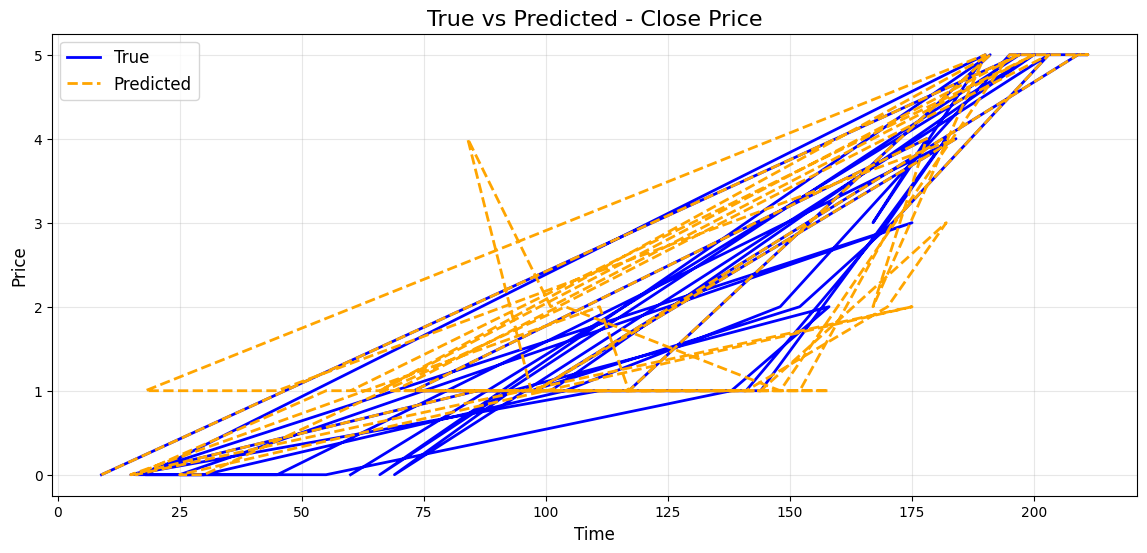

--------------------------------------------
MODEL: AdaBoostClassifier(learning_rate=0.1, n_estimators=100)
The accuracy in validation set it's: R2: 15.04%, mae:0.947, ac:45.61
The accuracy of in test set it's: R2: 45.86%, mae:0.767, ac:55.81%


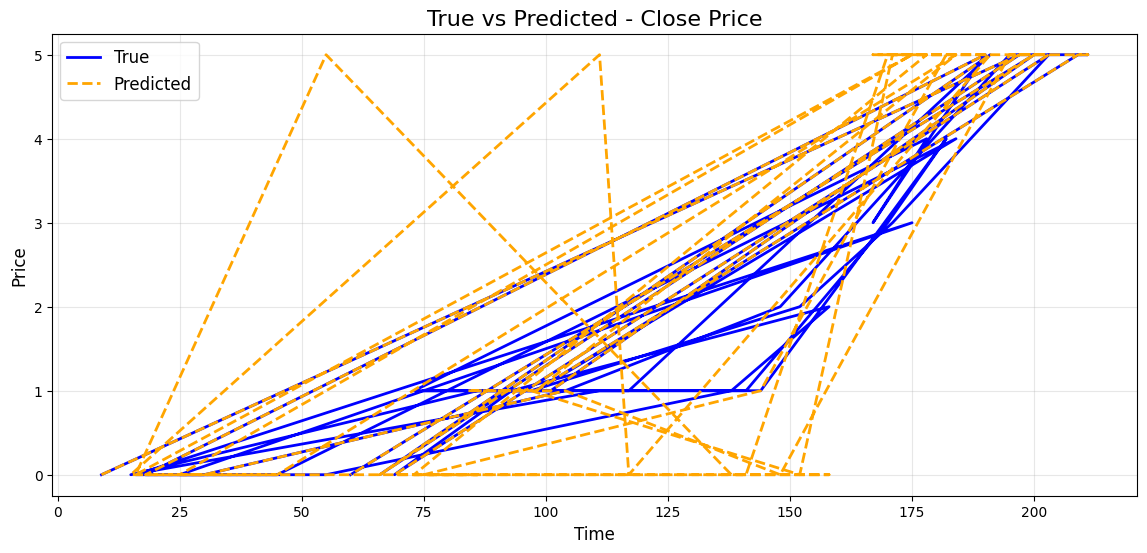

--------------------------------------------
MODEL: GradientBoostingClassifier()
The accuracy in validation set it's: R2: 100.00%, mae:0.000, ac:100.00
The accuracy of in test set it's: R2: 92.46%, mae:0.163, ac:88.37%


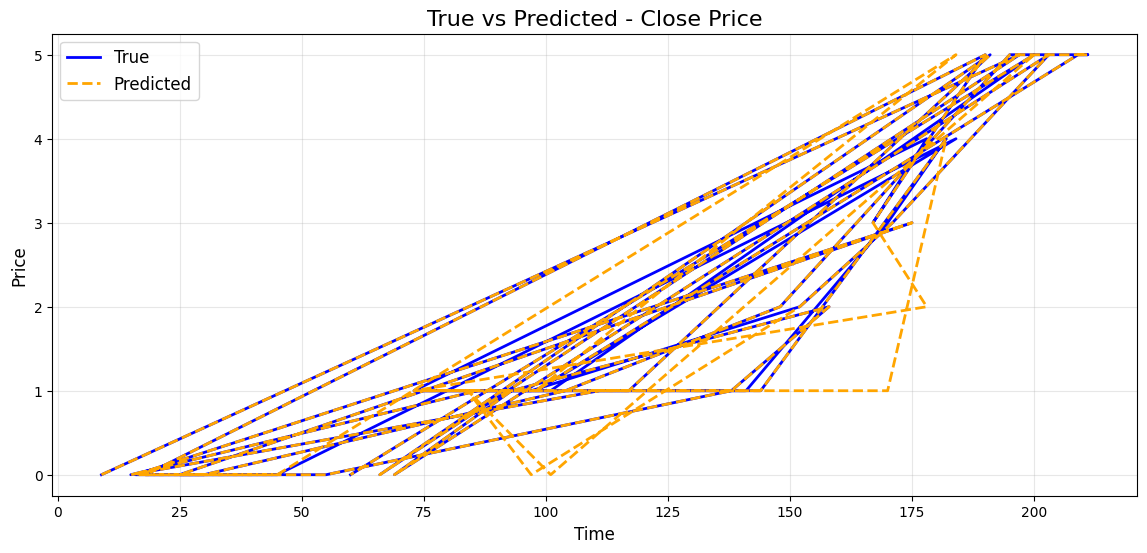

--------------------------------------------
MODEL: GradientBoostingRegressor()
The accuracy in validation set it's: R2: 98.50%, mae:0.041, ac:95.91
The accuracy of in test set it's: R2: 85.61%, mae:0.349, ac:72.09%


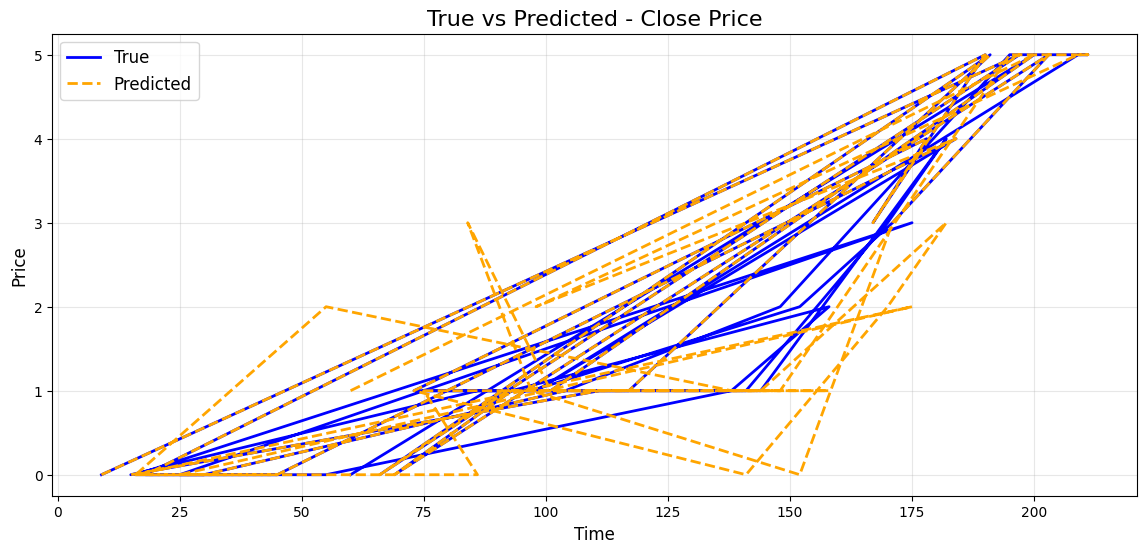

--------------------------------------------
MODEL: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
The accuracy in validation set it's: R2: 100.00%, mae:0.000, ac:100.00
The accuracy of in test set it's: R2: 76.70%, mae:0.326, ac:83.72%


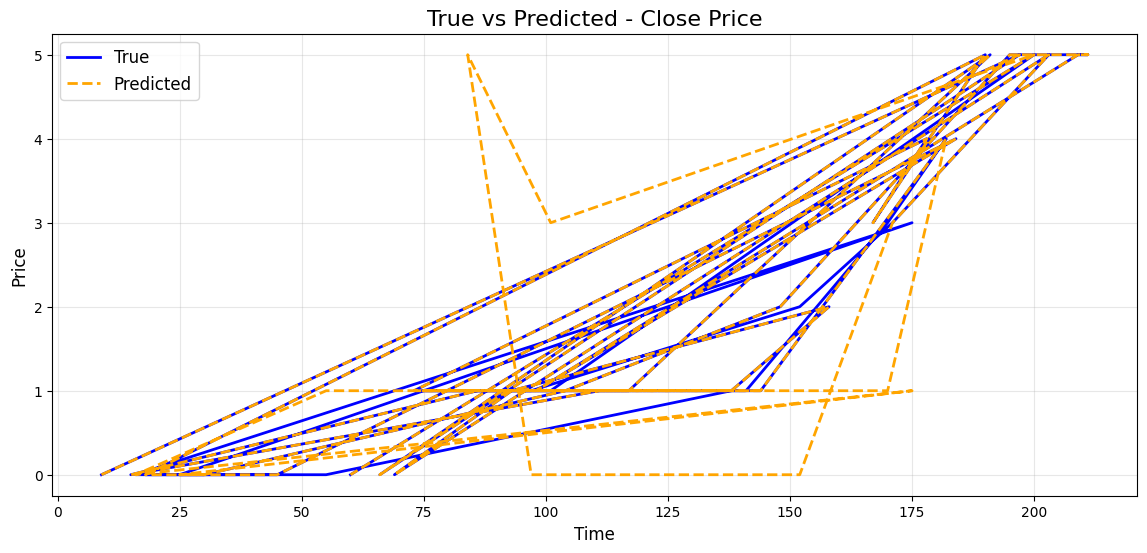

--------------------------------------------
MODEL: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
The accuracy in validation set it's: R2: 100.00%, mae:0.000, ac:100.00
The accuracy of in test set it's: R2: 76.01%, mae:0.395, ac:74.42%


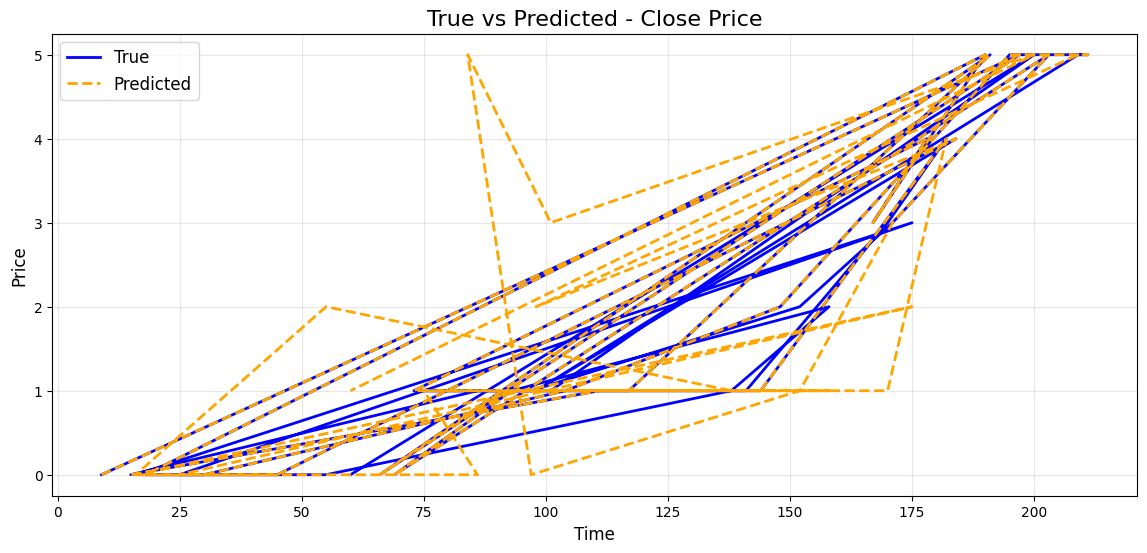

--------------------------------------------
MODEL: LGBMClassifier()
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000715 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 171, number of used features: 9
[LightGBM] [Info] Start training from score -1.064126
[LightGBM] [Info] Start training from score -1.014529
[LightGBM] [Info] Start training from score -2.502606
[LightGBM] [Info] Start training from score -2.944439
[LightGBM] [Info] Start training from score -3.349904
[LightGBM] [Info] Start training from score -2.097141
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

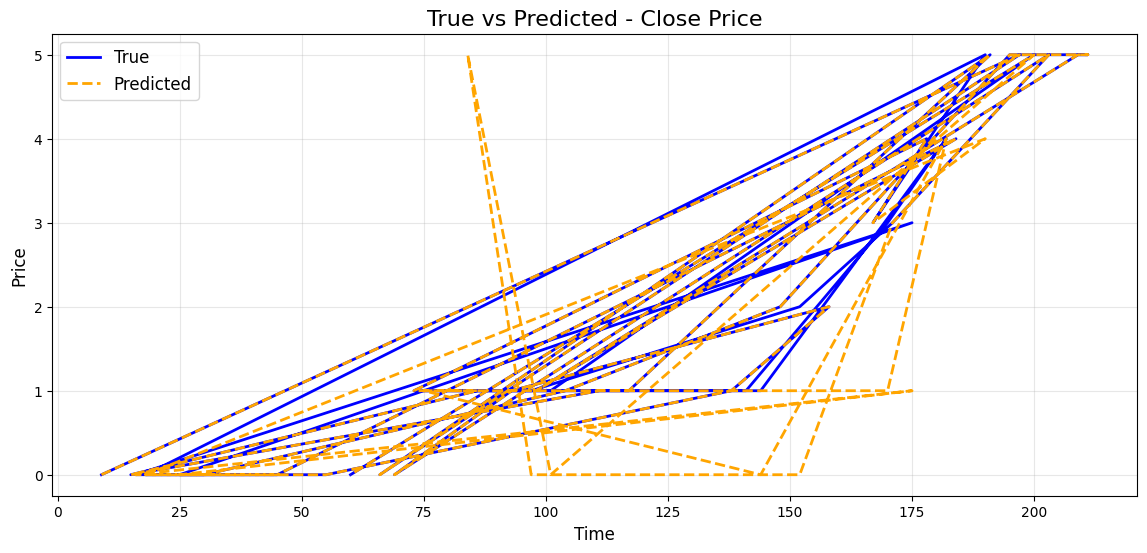

--------------------------------------------
MODEL: LGBMRegressor()
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 171, number of used features: 9
[LightGBM] [Info] Start training from score 1.438596
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

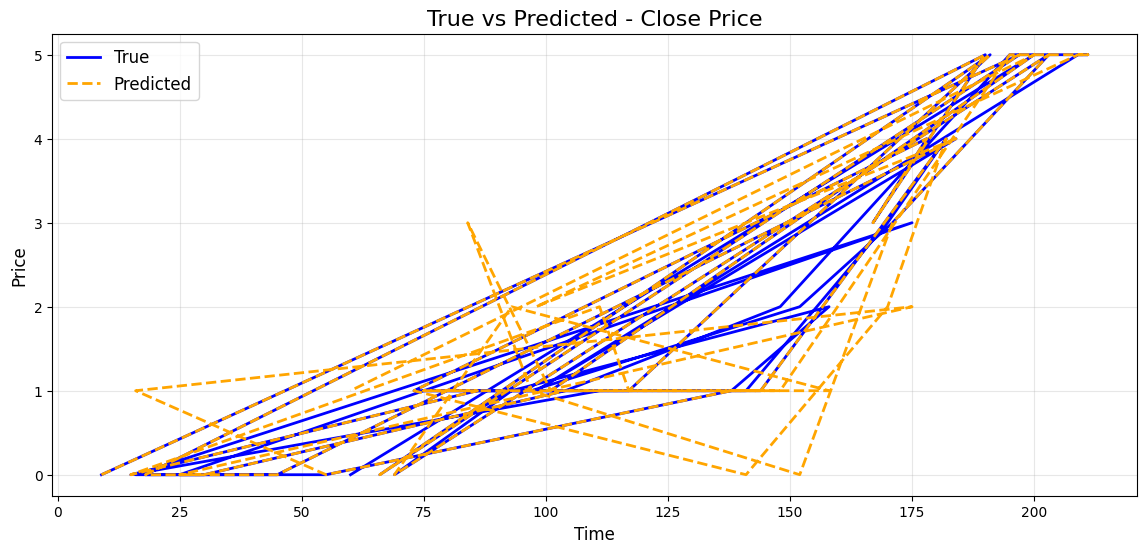






 O melhor modelo baseado no 'accuracy_score' foi o: GradientBoostingClassifier() com: 88.37 % de precisão


In [114]:
accuracys = []

for model in models:
        print('--------------------------------------------')
        print(f"MODEL: {model}")

        pipe = Pipeline(
                steps=[
                ('Scaler', StandardScaler()),
                ("Model", model)
                ]
        )
        # TRAIN THE MODEL
        pipe.fit(X_train, y_train)

        # SEE THE ACCURACY OF THE TRAIN
        y_preds_train = pipe.predict(X_train)
        y_preds_train = np.round(y_preds_train).astype(int)
        r2 = r2_score(y_train, y_preds_train)
        mae = mean_absolute_error(y_train, y_preds_train)
        ac_score = accuracy_score(y_preds_train, y_train)
        print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}, ac:{ac_score*100:.2f}")


        # SEE THE ACCURACY OF THE TEST
        y_preds_test = pipe.predict(X_test)
        y_preds_test = np.round(y_preds_test).astype(int)
        r2 = r2_score(y_test, y_preds_test)
        mae = mean_absolute_error(y_test, y_preds_test)
        ac_score = accuracy_score(y_preds_test, y_test)
        print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}, ac:{ac_score*100:.2f}%")
        accuracys.append(ac_score)

        plt.figure(figsize=(14,6))
        plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
        plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
        plt.title("True vs Predicted - Close Price", fontsize=16)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=12)
        plt.show()


print(f"\n\n\n\n\n O melhor modelo baseado no 'accuracy_score' foi o: {models[accuracys.index(max(accuracys))]} com: {max(accuracys)*100:.2f} % de precisão")